In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

df=pd.read_csv("../data/raw/pred_auto.csv",names=headers)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [37]:
df.shape

(205, 26)

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheel-base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


In [39]:
df.describe(include="object").T

,count,unique,top,freq
normalized-losses,205,52,?,41
make,205,22,toyota,32
fuel-type,205,2,gas,185
aspiration,205,2,std,168
num-of-doors,205,3,four,114
body-style,205,5,sedan,96
drive-wheels,205,3,fwd,120
engine-location,205,2,front,202
engine-type,205,7,ohc,148
num-of-cylinders,205,7,four,159


In [40]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

In [41]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [42]:
df.nunique()

symboling              6
normalized-losses     52
make                  22
fuel-type              2
aspiration             2
num-of-doors           3
body-style             5
drive-wheels           3
engine-location        2
wheel-base            53
length                75
width                 44
height                49
curb-weight          171
engine-type            7
num-of-cylinders       7
engine-size           44
fuel-system            8
bore                  39
stroke                37
compression-ratio     32
horsepower            60
peak-rpm              24
city-mpg              29
highway-mpg           30
price                187
dtype: int64

In [43]:
print(df['price'].head())   # is showing as object    ==>  a problem

0    13495
1    16500
2    16500
3    13950
4    17450
Name: price, dtype: object


In [44]:
df['price'] = pd.to_numeric(df['price'],errors='coerce')
print(df['price'].dtype)

float64


In [45]:
to_num=['normalized-losses','bore','stroke','horsepower','peak-rpm']
for columns in to_num:
    df[columns]=pd.to_numeric(df[columns],errors='coerce')

In [46]:
ord_cols=['symboling']
num_cols=[col for col in df.select_dtypes(include=["int64","float64"]).columns if col not in  ord_cols]
cat_cols=df.select_dtypes(include='object').columns



print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")
print(f"Ordinal columns: {ord_cols}")

Numerical columns: ['normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']
Categorical columns: Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')
Ordinal columns: ['symboling']


In [47]:
for cols in cat_cols:
    print(df[cols].nunique())

22
2
2
3
5
3
2
7
7
8


### Univariate Analysis
( One Variable at a time )

Numerical Features

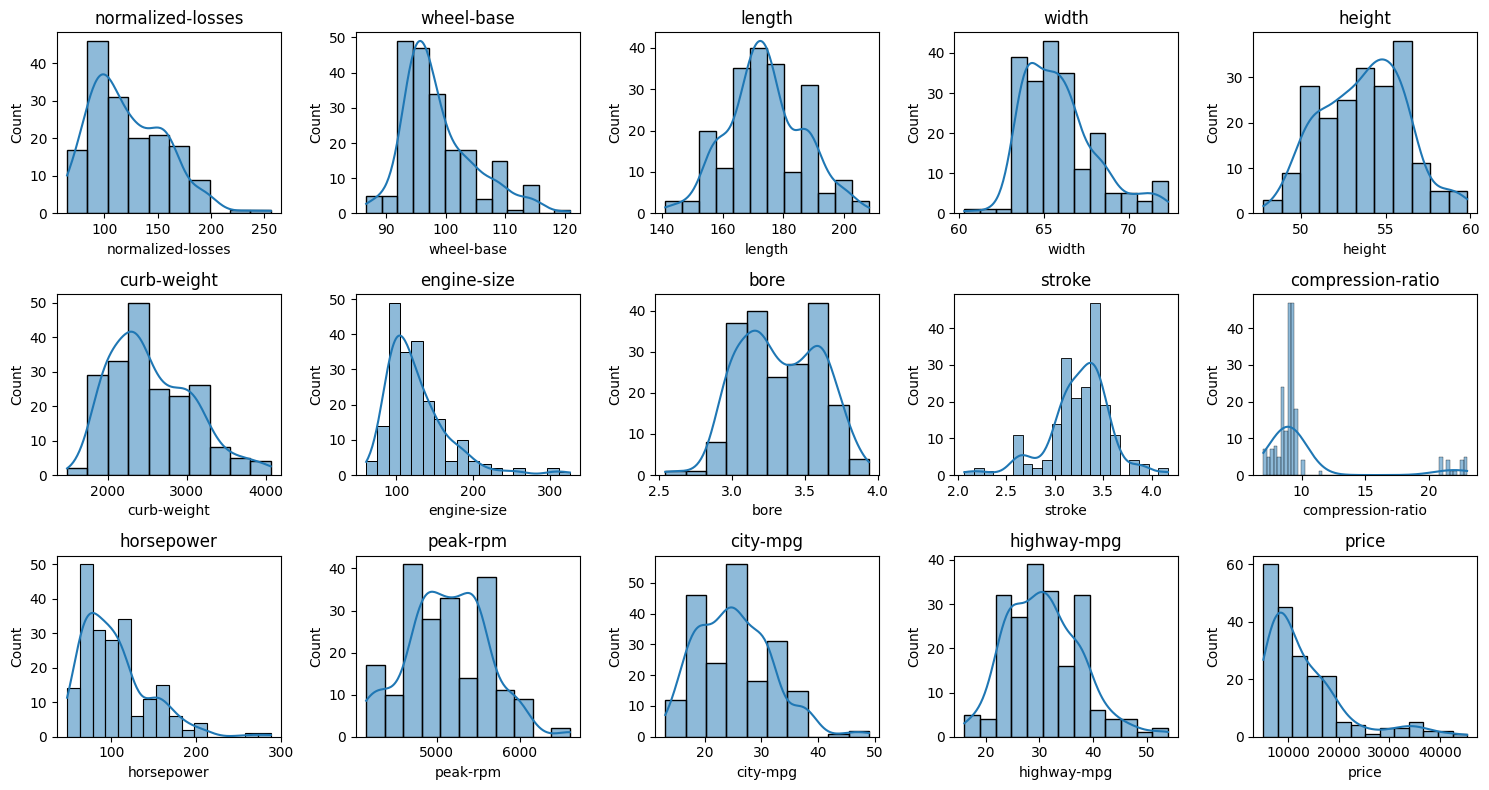

In [48]:
# Histogram

fig,axes=plt.subplots(3,5,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

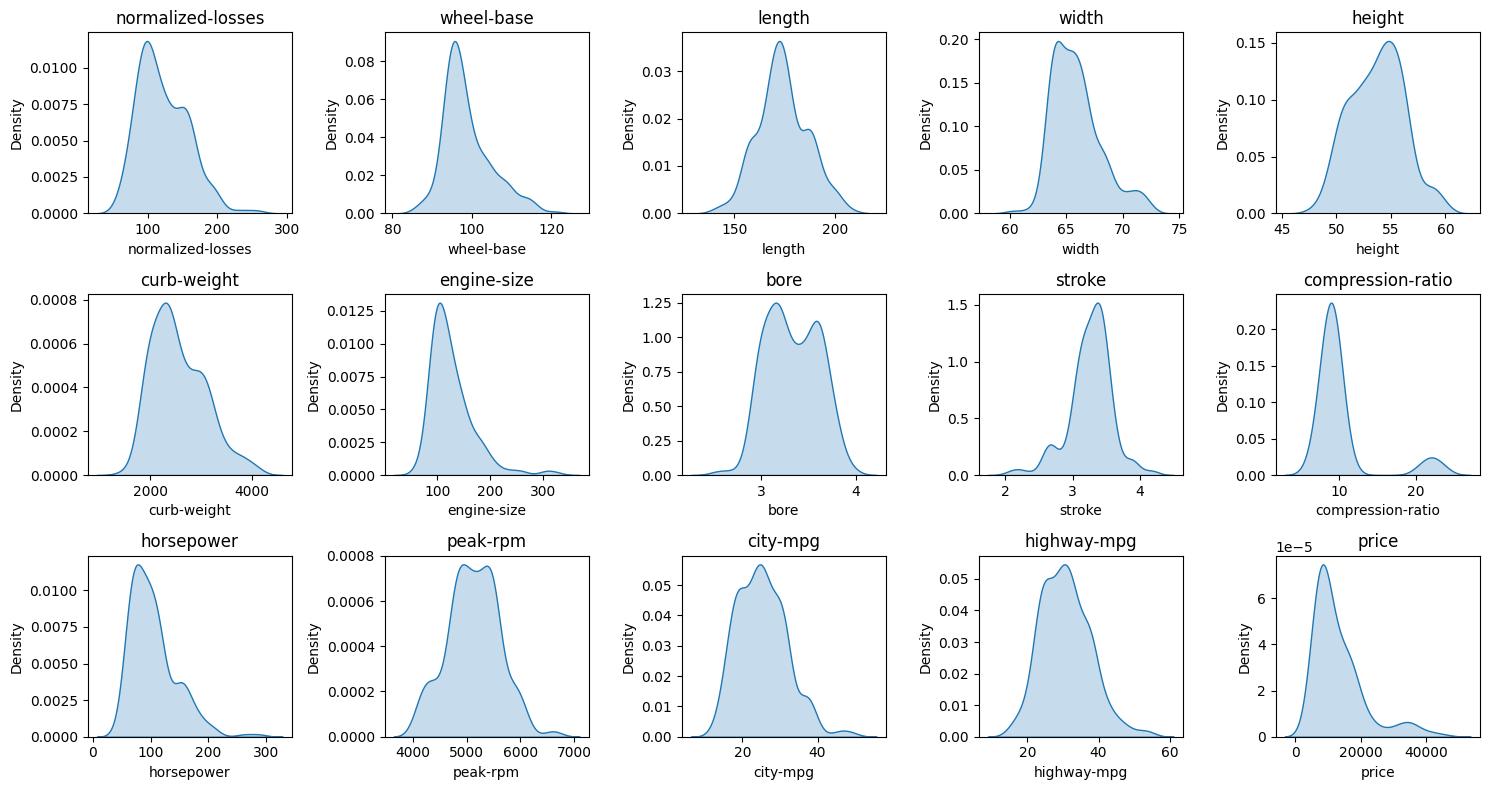

In [49]:
# KDE Plot ( Kernel Density Estimate )
fig,axes=plt.subplots(3,5,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.kdeplot(df[col],fill=True,ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

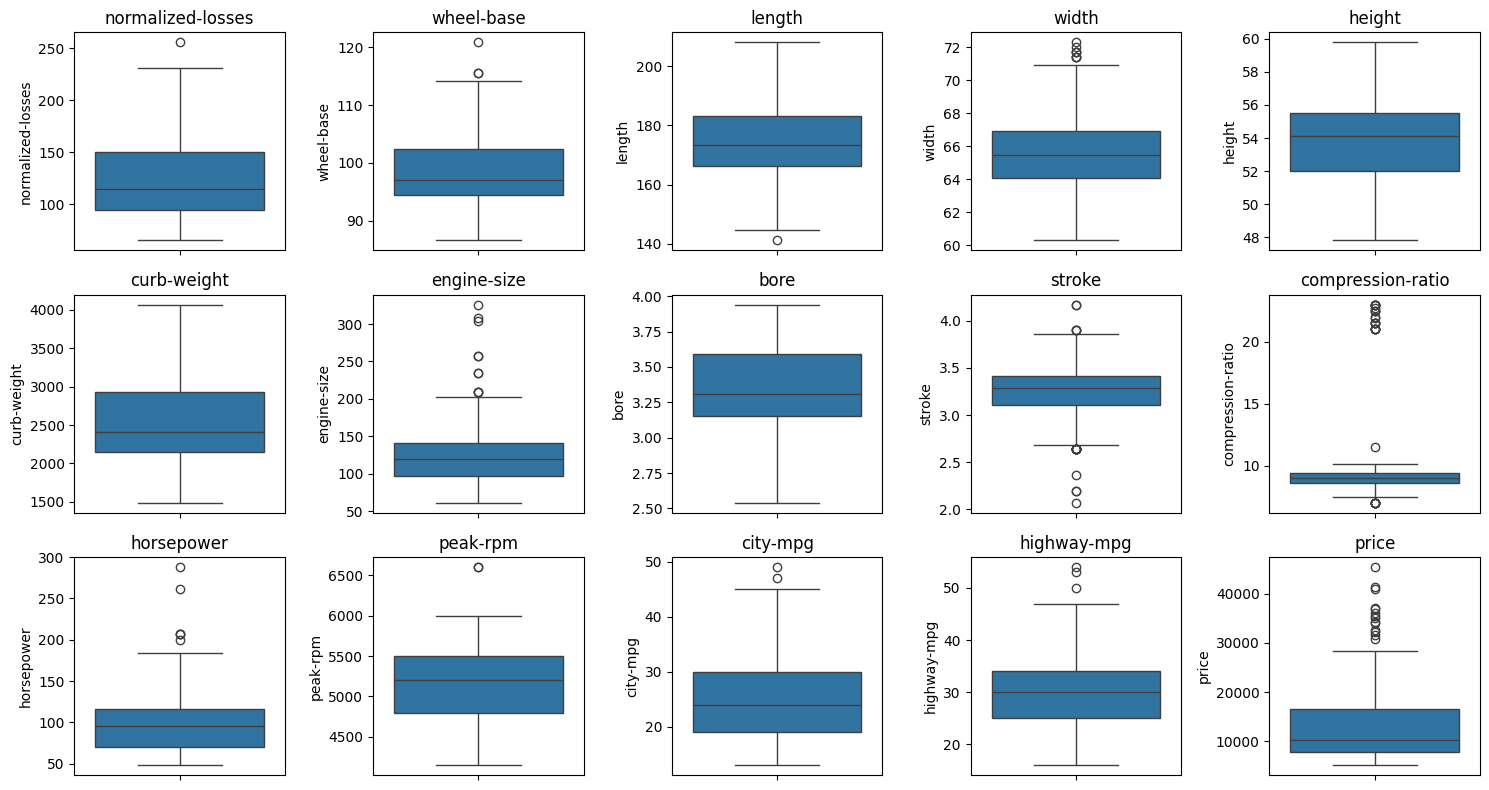

In [50]:
#  Box Plot
fig,axes=plt.subplots(3,5,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.boxplot(df[col],ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

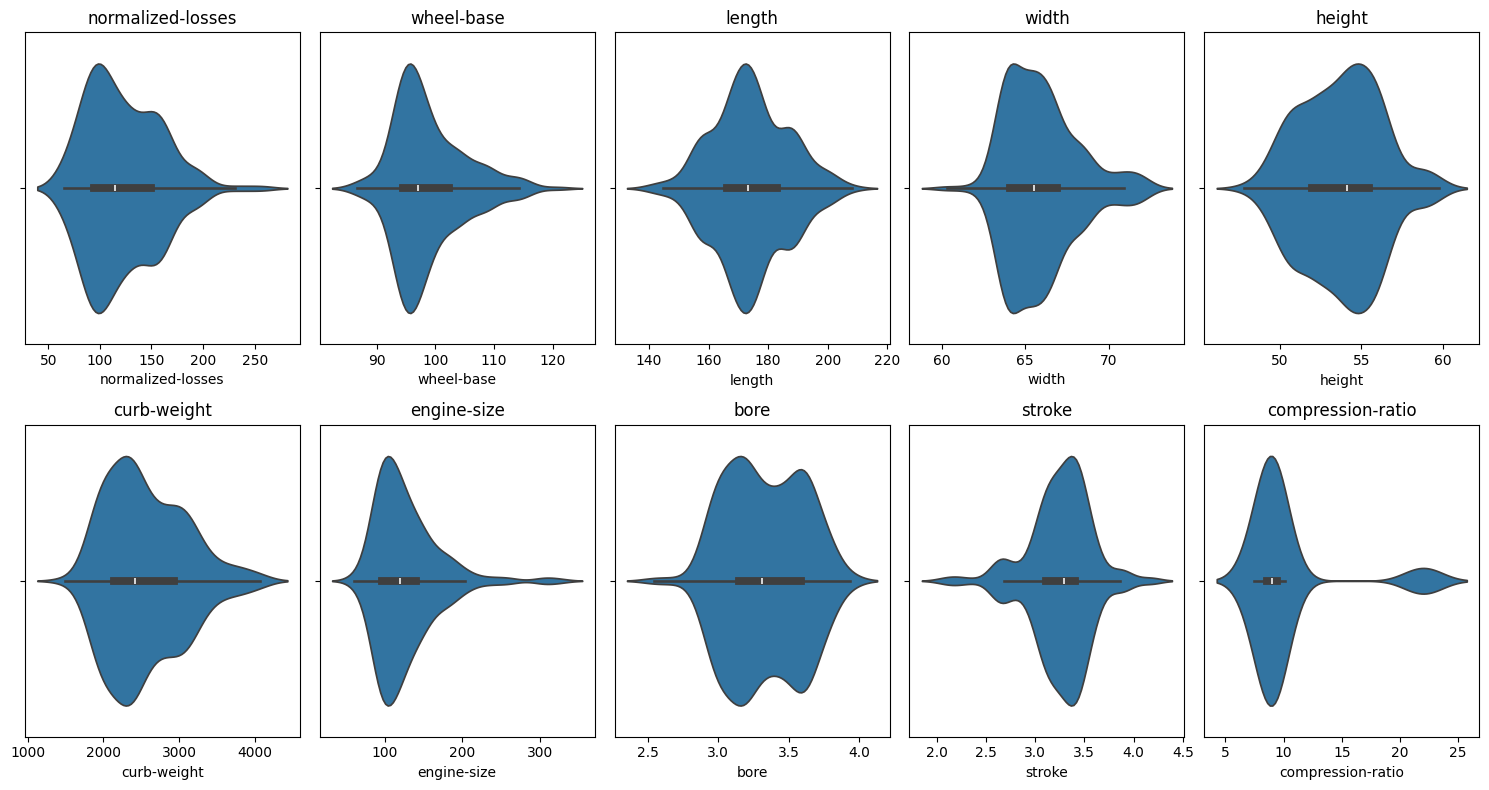

In [51]:
# Violin Plot
fig,axes=plt.subplots(2,5,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.violinplot(x=df[col],ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Categorical Features

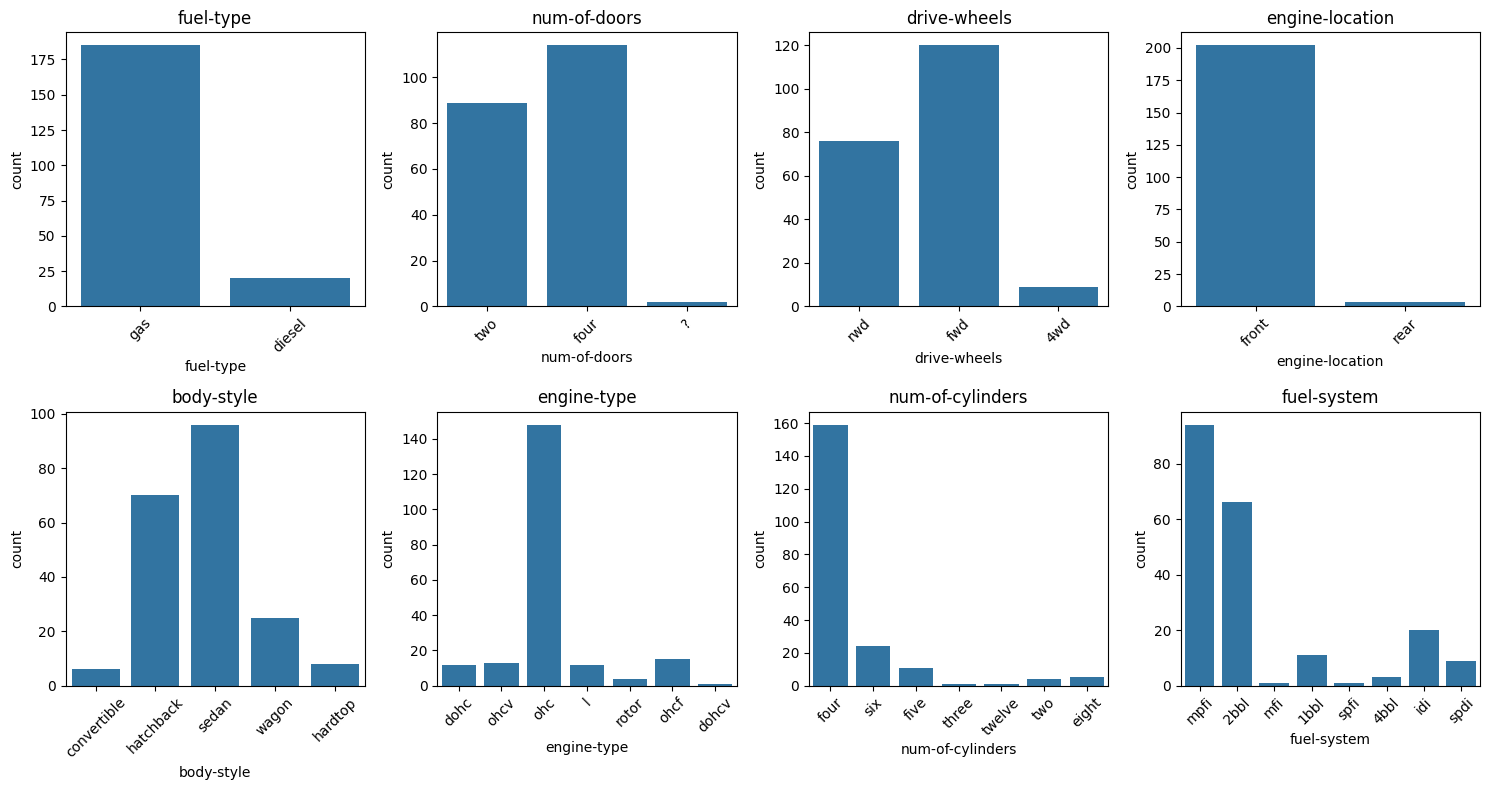

In [52]:
#  cCountplot
count=['fuel-type','num-of-doors','drive-wheels','engine-location','body-style','engine-type','num-of-cylinders','fuel-system']
# (randomly chosen for better understanding of categorical features with less unique values)

fig,axes=plt.subplots(2,4,figsize=(15,8))

for ax,col in zip(axes.flat,count):
    sns.countplot(x=df[col],ax=ax)
    ax.set_title(f'{col}')
    ax.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

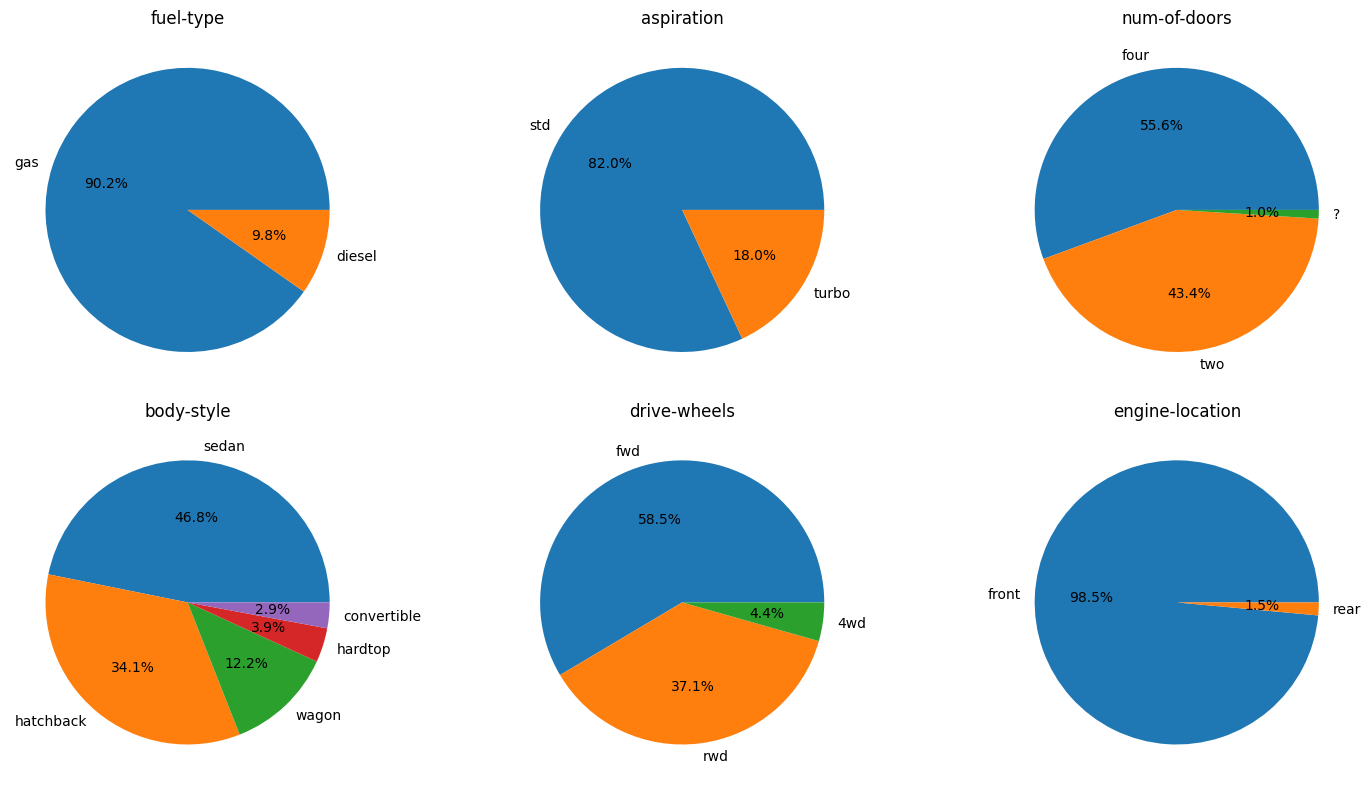

In [53]:
# Pie Chart

pie_cols=['fuel-type',
    'aspiration',
    'num-of-doors',
    'body-style',
    'drive-wheels',
    'engine-location']

fig,axes=plt.subplots(2,3,figsize=(15,8))

for ax,col in zip(axes.flat,pie_cols):
    
    df[col].value_counts().plot(kind='pie',autopct='%1.1f%%',ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('')
  
# Hide Remaining Axes 
for ax in axes.flat[len(pie_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()



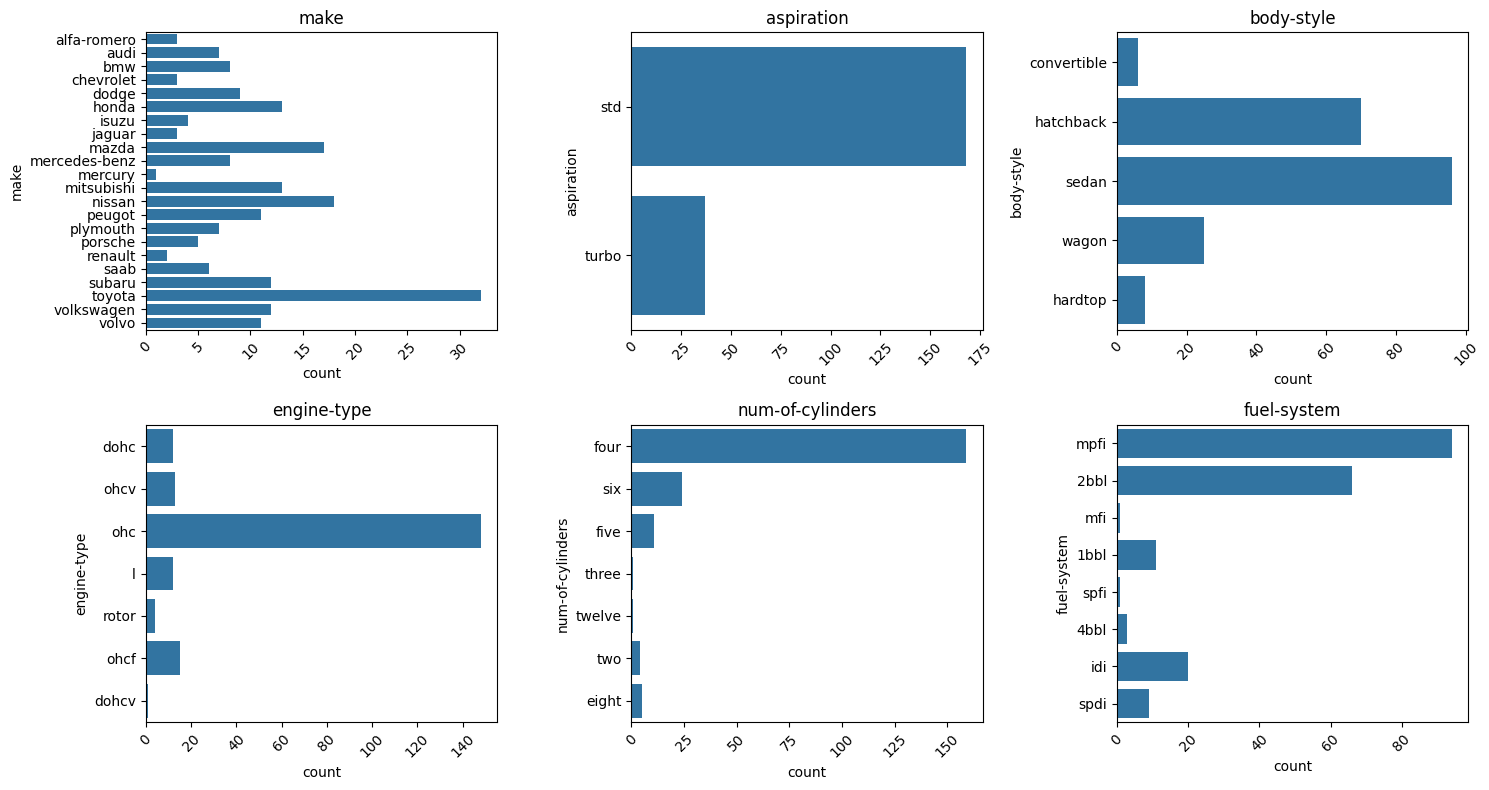

In [54]:
#  Bar Chart (horizontal countplot)
highcount=['make','aspiration','body-style','engine-type','num-of-cylinders','fuel-system']
# (randomly chosen for better understanding of categorical features with high cardinality {usually > 10})

fig,axes=plt.subplots(2,3,figsize=(15,8))

for ax,col in zip(axes.flat,highcount):
    sns.countplot(y=df[col],ax=ax)
    ax.set_title(f'{col}')
    ax.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

### Bivariate Analysis
- Relationship between Two Variables

Numerical vs Numerical

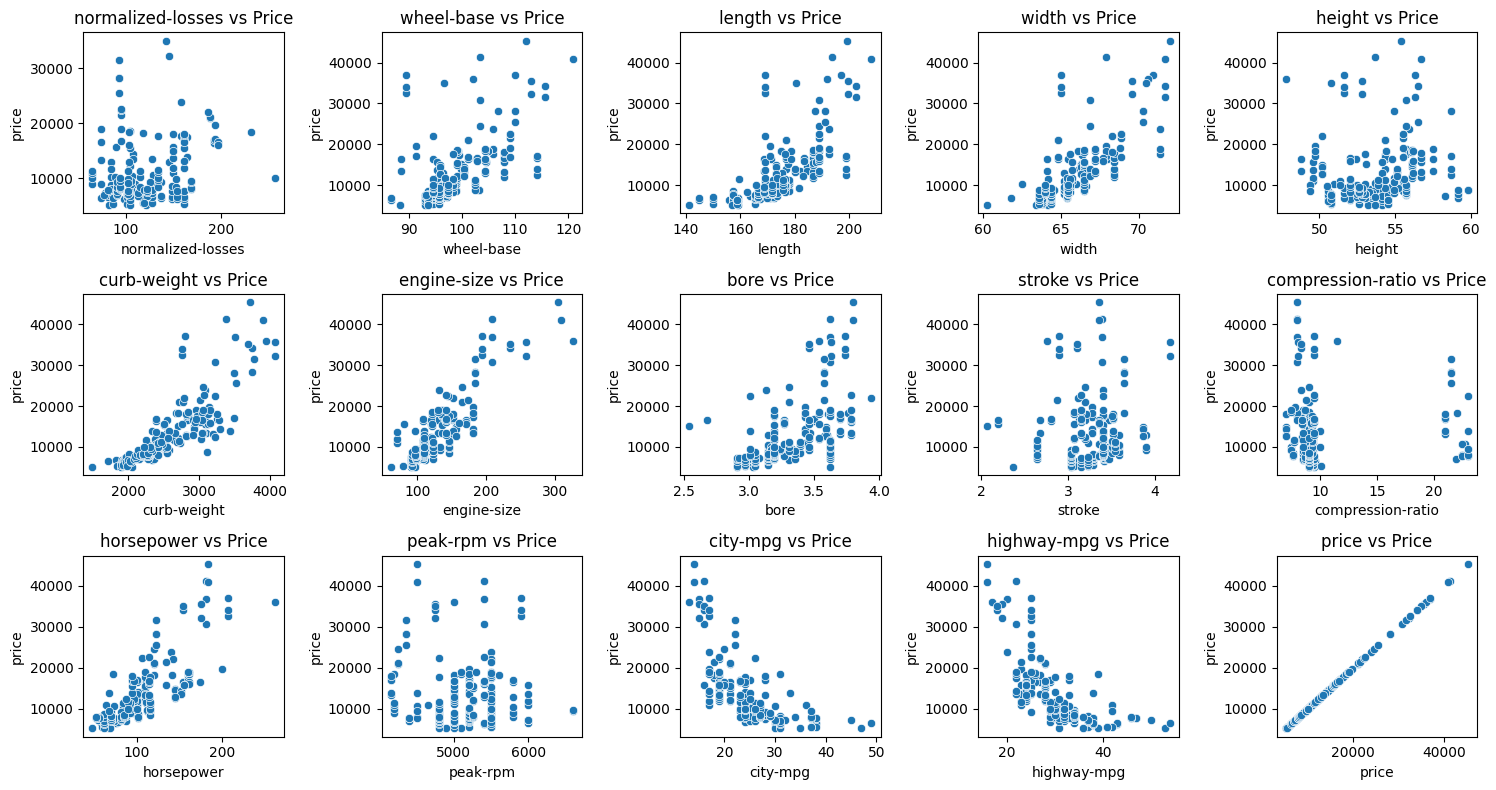

In [55]:
# ScatterPlot
fig,axes=plt.subplots(3,5,figsize=(15,8))

for ax,col in zip(axes.flat,num_cols):
    sns.scatterplot(x=df[col],y=df['price'],ax=ax)
    ax.set_title(f'{col} vs Price')

plt.tight_layout()
plt.show()

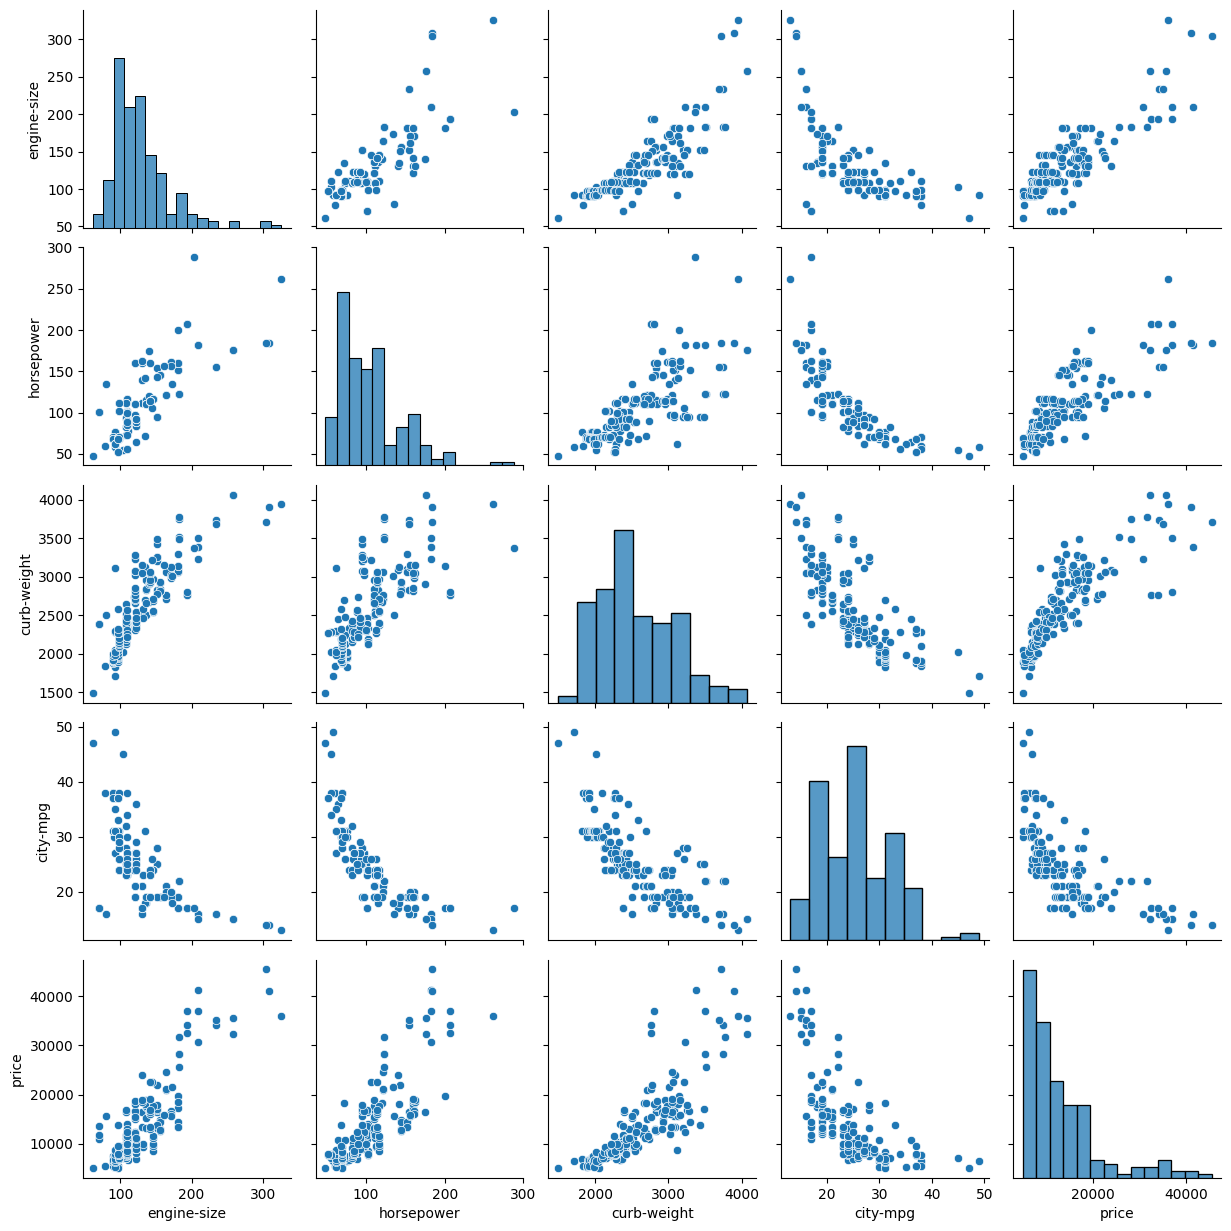

In [56]:
# Pair Plot

imp_cols=['engine-size','horsepower','curb-weight','city-mpg','price']

sns.pairplot(df[imp_cols])
plt.show()

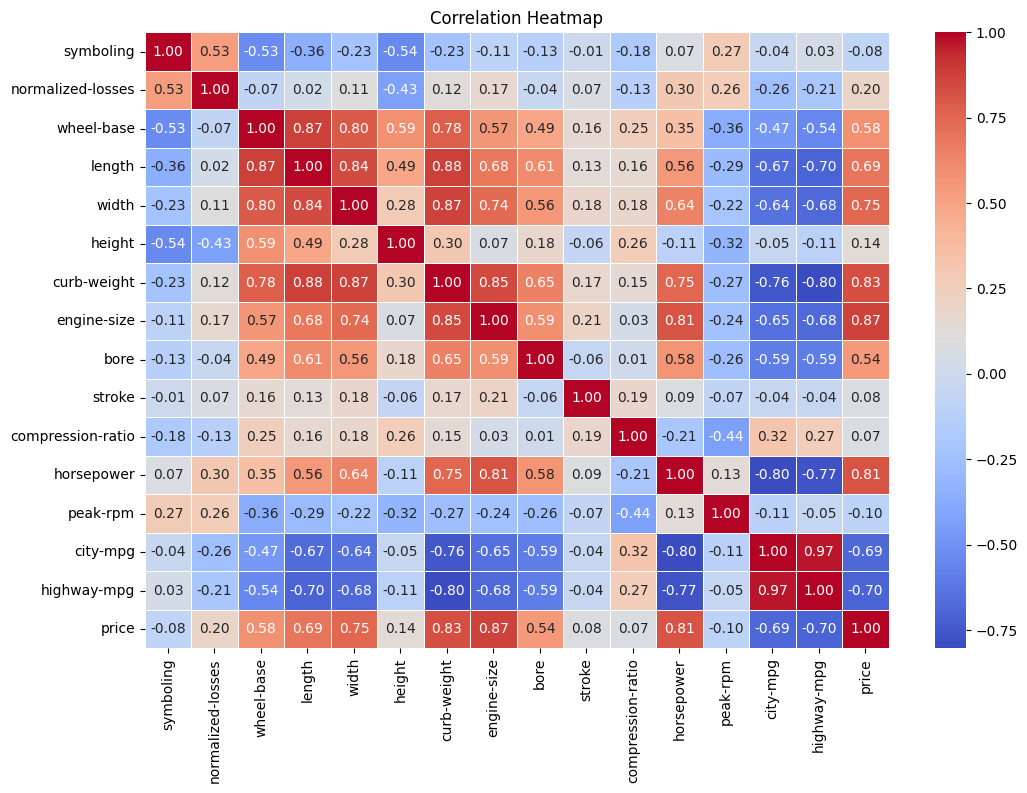

In [57]:
# Correaltion Heatmap

corr_matrix=df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

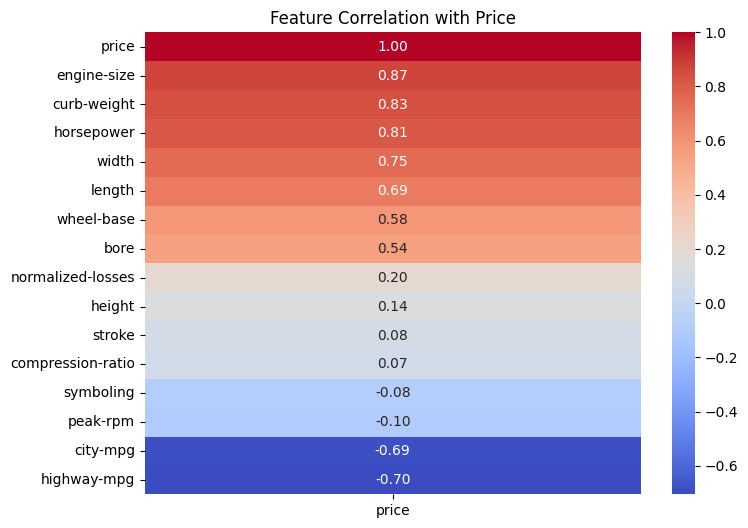

In [58]:
corr_price=(df.corr(numeric_only=True)['price'].sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(corr_price.to_frame(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Feature Correlation with Price')
plt.show()

Numerical vs Categorical 


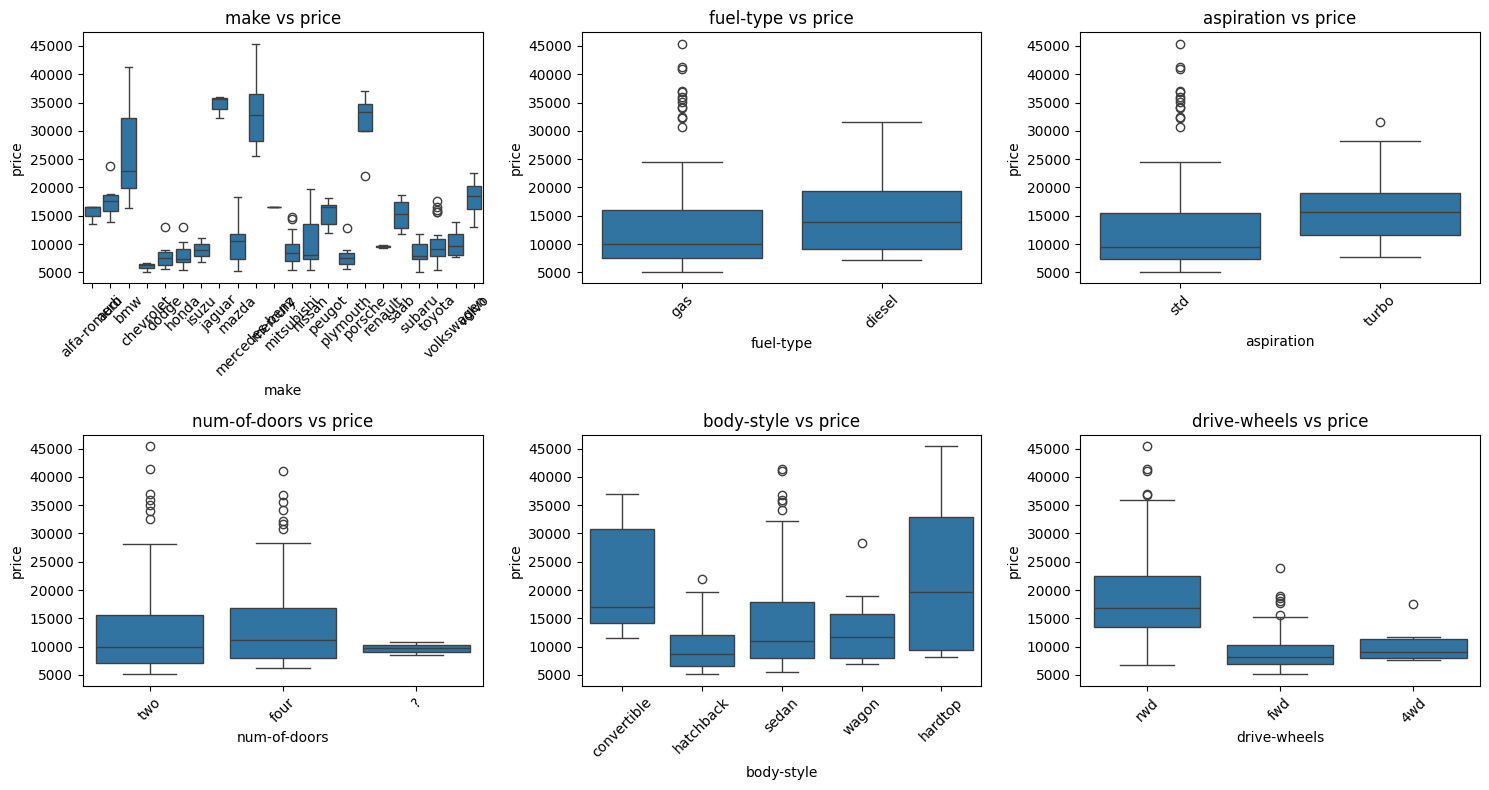

In [59]:
fig,axes=plt.subplots(2,3,figsize=(15,8))

for ax,col in zip(axes.flat,cat_cols):
    sns.boxplot(x=df[col],y=df['price'],ax=ax)
    ax.set_title(f'{col} vs price')
    ax.tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

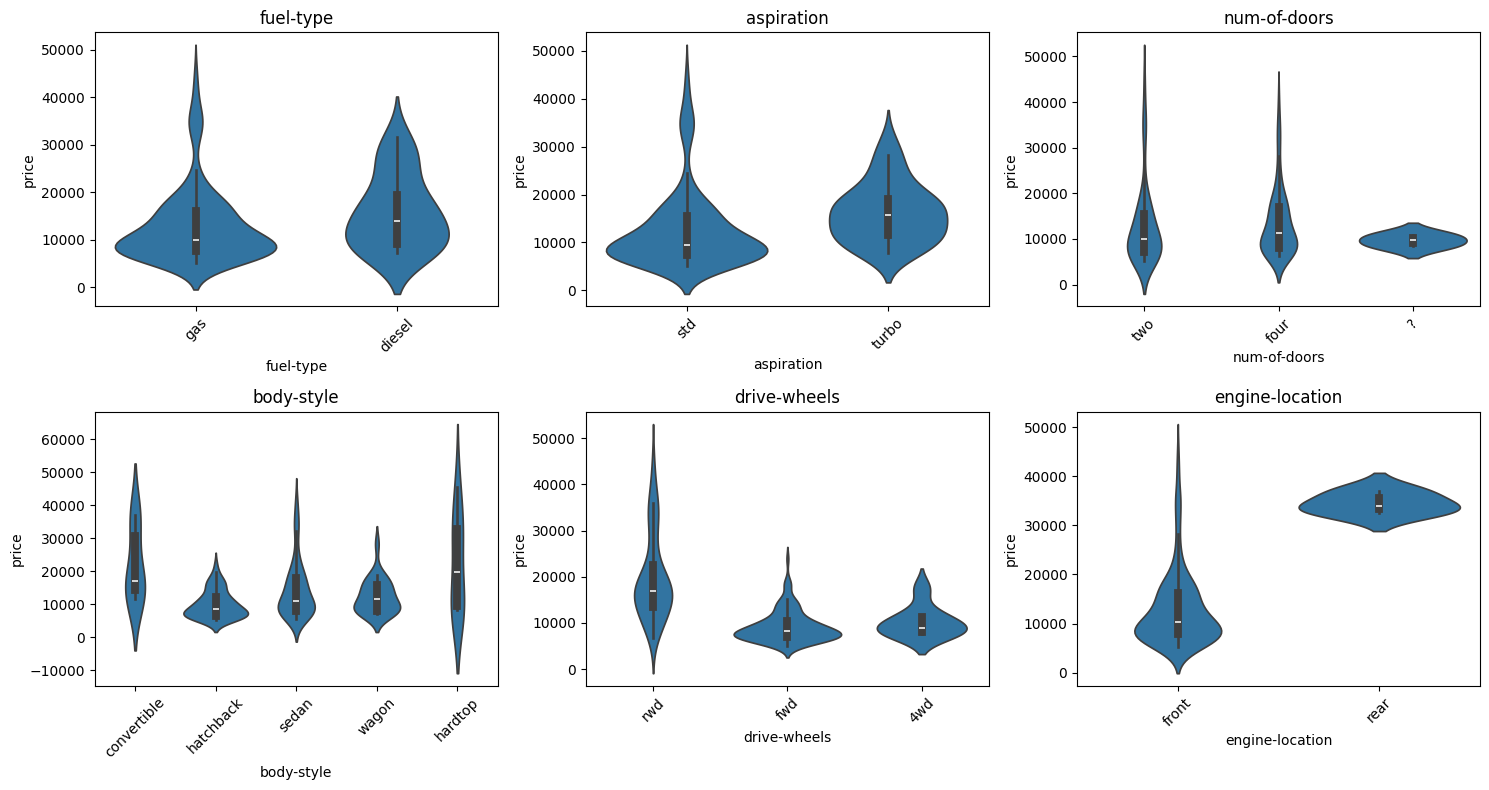

In [60]:
# Violin plot
low_card_cols = [
    col for col in cat_cols
    if df[col].nunique() <= 10
]

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flat, low_card_cols):

    sns.violinplot(
        x=df[col],
        y=df['price'],
        ax=ax
    )

    ax.tick_params(axis='x', rotation=45)

    ax.set_title(col)

plt.tight_layout()
plt.show()

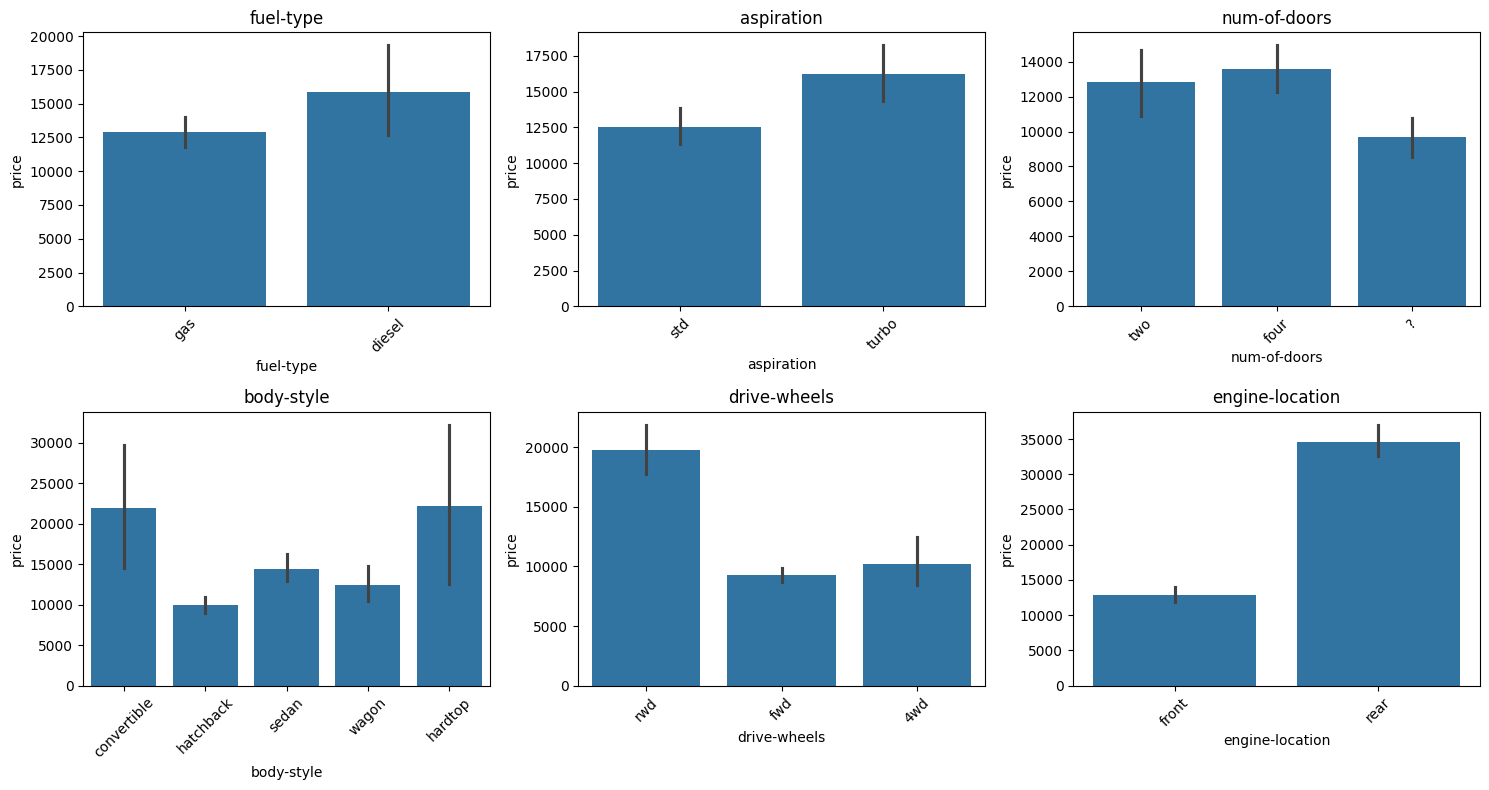

In [61]:
#  Barplot

fig, axes = plt.subplots(2, 3, figsize=(15,8))

for ax, col in zip(axes.flat, low_card_cols):

    sns.barplot(
        x=df[col],
        y=df['price'],
        ax=ax
    )

    ax.tick_params(axis='x', rotation=45)

    ax.set_title(col)

plt.tight_layout()
plt.show()

Categorical vs Categorical

In [62]:
# Crosstab Table

pd.crosstab(
    df['fuel-type'],
    df['drive-wheels']
)

drive-wheels,4wd,fwd,rwd
fuel-type,,,
diesel,0,9,11
gas,9,111,65


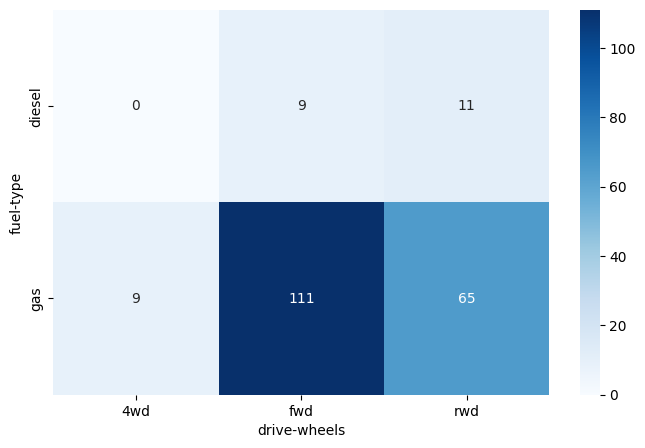

In [63]:
# Crosstab Heatmap
cross_tab = pd.crosstab(
    df['fuel-type'],
    df['drive-wheels']
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

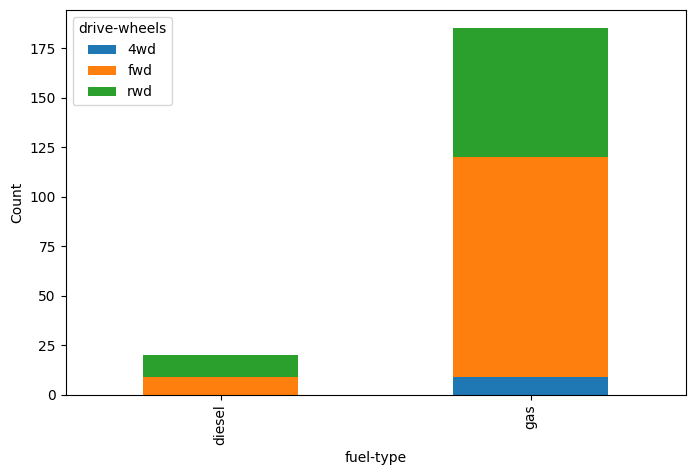

In [64]:
# Stacked Bar Chart
cross_tab = pd.crosstab(
    df['fuel-type'],
    df['drive-wheels']
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.ylabel('Count')

plt.show()

### Multivariate Analysis

- Pairplot
- Heatmap
( as above )
- Feature Interaction Analysis (Categorical + Numerical + Target)


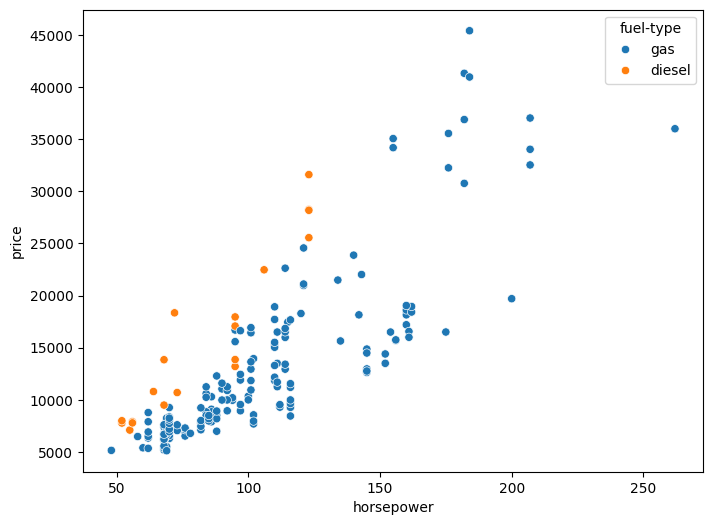

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='horsepower',
    y='price',
    hue='fuel-type',
    data=df
)

plt.show()

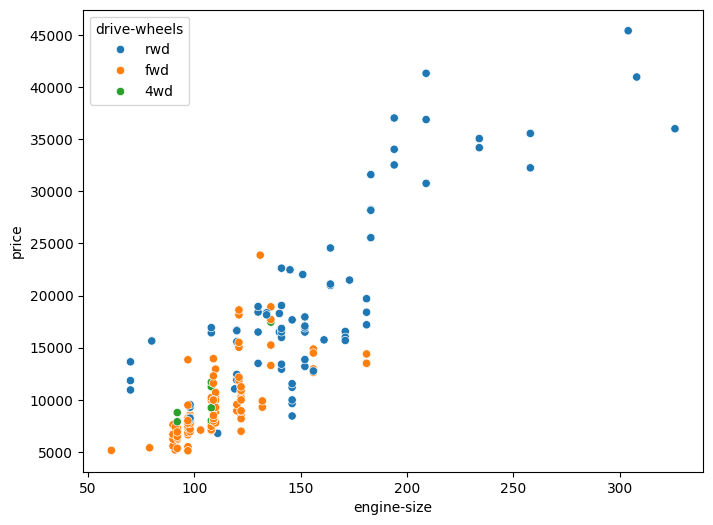

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='engine-size',
    y='price',
    hue='drive-wheels',
    data=df
)

plt.show()

## Conclusions from EDA
- Feature distributions
- Skewness
- Correlations
- Outliers
- Important trends
- Business insights

In [67]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,NaN


In [68]:
df.to_csv('../data/raw/used_car.csv')